# Public Transport Delay Prediction using Machine Learning

## Business Problem

Public transportation systems are critical for urban mobility. Delays caused by weather conditions, traffic congestion, holidays, public events, and operational issues reduce passenger satisfaction and increase operational costs.

The objective of this project is to develop a machine learning model capable of predicting whether a public transport trip will be delayed based on scheduling information, weather conditions, traffic levels, and city events.

Such predictions can help transport authorities:

- Improve operational planning
- Optimize route scheduling
- Inform passengers proactively
- Reduce congestion
- Improve service reliability

---

## Project Objectives

This project aims to:

- Understand the dataset through Exploratory Data Analysis (EDA)
- Identify important factors contributing to transport delays
- Engineer meaningful features
- Build multiple Machine Learning models
- Compare model performance
- Explain predictions using Explainable AI (SHAP)

---

## Dataset Overview

The dataset contains information related to

- Transport schedules
- Weather
- Traffic conditions
- Public events
- Holidays
- Peak hours
- Delay information

Target Variable

**Delayed**

- 0 → On Time
- 1 → Delayed

Dataset Link: https://www.kaggle.com/datasets/khushikyad001/public-transport-delays-with-weather-and-events/data

In [16]:
#import libraries 

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

In [17]:
#load dataset

df = pd.read_csv("../data/public_transport_delays.csv")
df.head()

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,46,13.0,NaN,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,11,11.4,NaN,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,41,6.4,NaN,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,30,18.5,NaN,500,46,0,0,6,Spring,1


In [18]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 2000
Number of Columns : 24


In [19]:
df.columns

Index(['trip_id', 'date', 'time', 'transport_type', 'route_id',
       'origin_station', 'destination_station', 'scheduled_departure',
       'scheduled_arrival', 'actual_departure_delay_min',
       'actual_arrival_delay_min', 'weather_condition', 'temperature_C',
       'humidity_percent', 'wind_speed_kmh', 'precipitation_mm', 'event_type',
       'event_attendance_est', 'traffic_congestion_index', 'holiday',
       'peak_hour', 'weekday', 'season', 'delayed'],
      dtype='object')

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     2000 non-null   object 
 1   date                        2000 non-null   object 
 2   time                        2000 non-null   object 
 3   transport_type              2000 non-null   object 
 4   route_id                    2000 non-null   object 
 5   origin_station              2000 non-null   object 
 6   destination_station         2000 non-null   object 
 7   scheduled_departure         2000 non-null   object 
 8   scheduled_arrival           2000 non-null   object 
 9   actual_departure_delay_min  2000 non-null   int64  
 10  actual_arrival_delay_min    2000 non-null   int64  
 11  weather_condition           2000 non-null   object 
 12  temperature_C               2000 non-null   float64
 13  humidity_percent            2000 

In [21]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
actual_departure_delay_min,2000.0,8.68800,6.268118,-2.0,3.0,9.0,14.0,19.0
actual_arrival_delay_min,2000.0,13.31800,9.289727,-3.0,5.0,13.0,21.0,29.0
temperature_C,2000.0,15.12135,11.479424,-5.0,5.1,15.3,24.8,35.0
humidity_percent,2000.0,64.71400,20.334747,30.0,46.0,65.0,83.0,99.0
wind_speed_kmh,2000.0,29.30050,17.264015,0.0,15.0,29.0,45.0,59.0
precipitation_mm,2000.0,9.86070,5.781373,0.0,4.9,9.7,14.8,20.0
event_attendance_est,2000.0,6420.25000,15198.306129,0.0,0.0,0.0,2000.0,50000.0
traffic_congestion_index,2000.0,50.24400,29.225751,0.0,25.0,50.0,76.0,99.0
holiday,2000.0,0.08950,0.285535,0.0,0.0,0.0,0.0,1.0
peak_hour,2000.0,0.27200,0.445101,0.0,0.0,0.0,1.0,1.0


In [22]:
df.describe(include="object").T

,count,unique,top,freq
trip_id,2000,2000,T00000,1
date,2000,22,2023-01-12,96
time,2000,96,05:00:00,21
transport_type,2000,4,Bus,525
route_id,2000,20,Route_3,114
origin_station,2000,50,Station_17,55
destination_station,2000,50,Station_26,56
scheduled_departure,2000,474,11:46:00,11
scheduled_arrival,2000,1068,12:43:00,7
weather_condition,2000,6,Clear,343


The dataset contains information about public transport trips, including schedule, delays, weather, traffic, and special events.

# Categorical Columns
trip_id : Unique ID for each trip 
>
transport_type : Type of transport (bus, train, etc.)
>
route_id : Route identifier
>
origin_station : Starting station
>
destination_station : Ending station
>
weather_condition : Weather description
>
event_type : Type of event (if any)
holiday : Whether the day is a public holiday
>
peak_hour : Whether the trip occurs during peak hours
>
weekday : Day of the week
>
season : Season
>
delayed : Whether the trip was delayed (0 = No, 1 = Yes)
>
# Numeric Columns
temperature_C : Temperature in Celsius
>
humidity_percent : Humidity (%)
>
wind_speed_kmh : Wind speed (km/h)
>
precipitation_mm : Precipitation (mm)
>
event_attendance_est : Estimated number of people attending the event
>
traffic_congestion_index : Traffic congestion level
>
actual_departure_delay_min : Departure delay in minutes
>
actual_arrival_delay_min : Arrival delay in minutes
>
# Datetime Columns
>
date : Date of the trip
>
time : Time of the trip
>
scheduled_departure : Scheduled departure time
>
scheduled_arrival : Scheduled arrival time

In [23]:
#Data Quality Report

report = pd.DataFrame({

"Data Type":df.dtypes,

"Missing Values":df.isnull().sum(),

"Missing %":round(df.isnull().sum()/len(df)*100,2),

"Unique Values":df.nunique(),

"Duplicate":df.duplicated().sum()

})

report

,Data Type,Missing Values,Missing %,Unique Values,Duplicate
trip_id,object,0,0.00,2000,0
date,object,0,0.00,22,0
time,object,0,0.00,96,0
transport_type,object,0,0.00,4,0
route_id,object,0,0.00,20,0
origin_station,object,0,0.00,50,0
destination_station,object,0,0.00,50,0
scheduled_departure,object,0,0.00,474,0
scheduled_arrival,object,0,0.00,1068,0
actual_departure_delay_min,int64,0,0.00,22,0


In [24]:
#Memory usage

memory = df.memory_usage(deep=True)

memory

Index                            128
trip_id                       126000
date                          134000
time                          130000
transport_type                122459
route_id                      129091
origin_station                133663
destination_station           133661
scheduled_departure           130000
scheduled_arrival             130000
actual_departure_delay_min     16000
actual_arrival_delay_min       16000
weather_condition             122999
temperature_C                  16000
humidity_percent               16000
wind_speed_kmh                 16000
precipitation_mm               16000
event_type                     90368
event_attendance_est           16000
traffic_congestion_index       16000
holiday                        16000
peak_hour                      16000
weekday                        16000
season                        126000
delayed                        16000
dtype: int64

In [25]:
#Total memory

print(f"Memory Usage : {memory.sum()/1024**2:.2f} MB")

Memory Usage : 1.62 MB


In [26]:
#Missing value analysis

missing = pd.DataFrame({

"Missing":df.isnull().sum(),

"Percentage":round(df.isnull().sum()/len(df)*100,2)

})

missing = missing.sort_values("Percentage",ascending=False)

missing

,Missing,Percentage
event_type,1173,58.65
trip_id,0,0.00
date,0,0.00
season,0,0.00
weekday,0,0.00
peak_hour,0,0.00
holiday,0,0.00
traffic_congestion_index,0,0.00
event_attendance_est,0,0.00
precipitation_mm,0,0.00


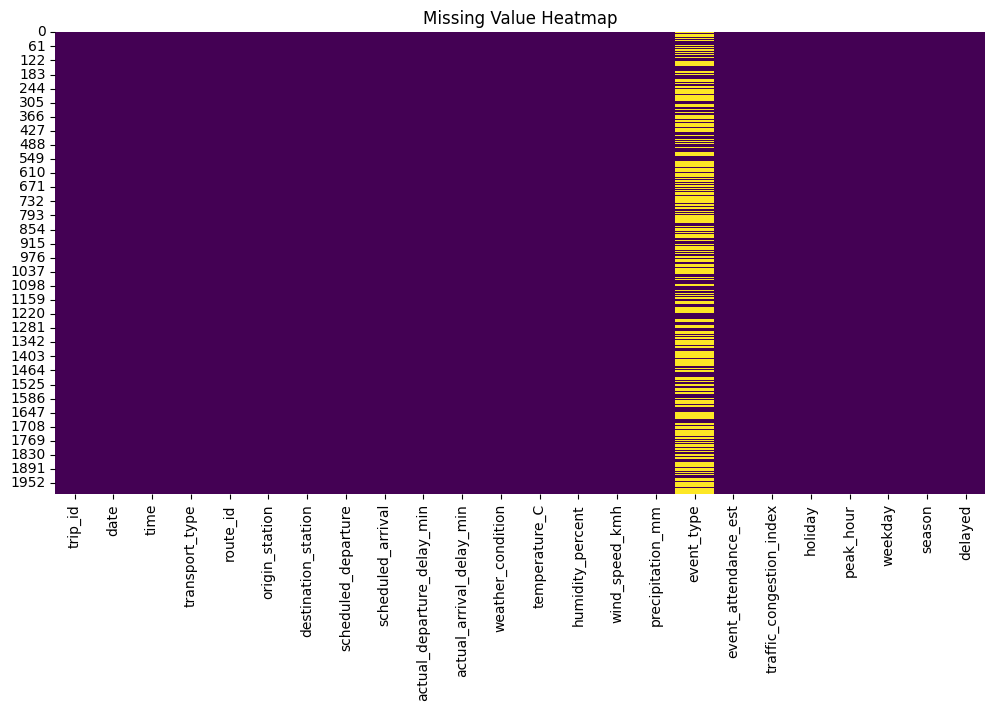

In [27]:
plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(),
            cmap="viridis",
            cbar=False)

plt.title("Missing Value Heatmap")

plt.show()

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


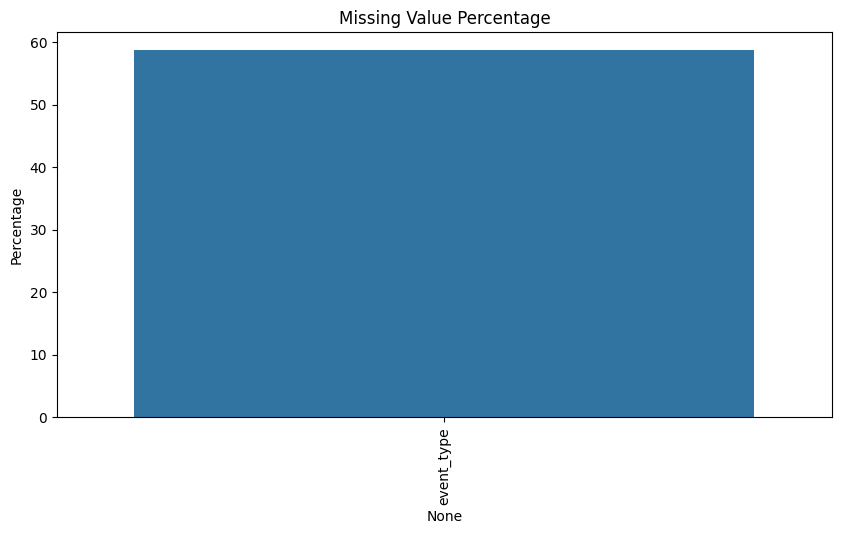

In [28]:
#barplot

missing = missing[missing["Missing"]>0]

plt.figure(figsize=(10,5))

sns.barplot(
    x=missing.index,
    y=missing["Percentage"]
)

plt.xticks(rotation=90)

plt.title("Missing Value Percentage")

plt.show()

In [29]:
# Duplicate Analysis

duplicates = df.duplicated().sum()

print("Duplicate Rows :",duplicates)

Duplicate Rows : 0


In [30]:
#Unique Values

for col in df.columns:

    print("="*40)

    print(col)

    print(df[col].nunique())

trip_id
2000
date
22
time
96
transport_type
4
route_id
20
origin_station
50
destination_station
50
scheduled_departure
474
scheduled_arrival
1068
actual_departure_delay_min
22
actual_arrival_delay_min
33
weather_condition
6
temperature_C
397
humidity_percent
70
wind_speed_kmh
60
precipitation_mm
201
event_type
5
event_attendance_est
5
traffic_congestion_index
100
holiday
2
peak_hour
2
weekday
7
season
4
delayed
2


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the distribution, patterns,
relationships, and potential anomalies present in the dataset.

The analysis focuses on:

- Univariate analysis of individual variables
- Numerical variable distributions
- Categorical variable distributions
- Target variable distribution
- Relationships between features and transport delays
- Correlation between numerical variables
- Identification of patterns related to weather, traffic, events and scheduling

In [32]:
# Target variable distribution

print("Target Variable: delayed")
print("\nValue Counts:")
print(df['delayed'].value_counts())

print("\nPercentage Distribution:")
print(df['delayed'].value_counts(normalize=True) * 100)

Target Variable: delayed

Value Counts:
delayed
1    1499
0     501
Name: count, dtype: int64

Percentage Distribution:
delayed
1    74.95
0    25.05
Name: proportion, dtype: float64


C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


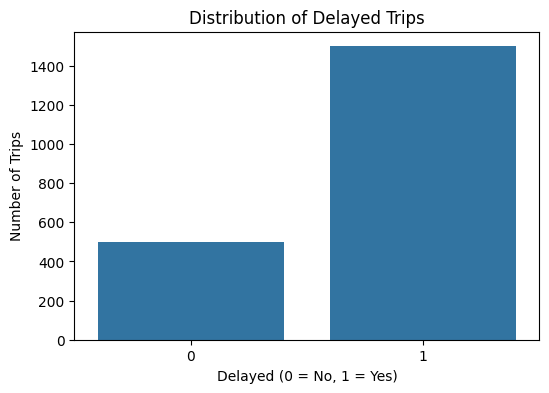

In [33]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='delayed')

plt.title('Distribution of Delayed Trips')
plt.xlabel('Delayed (0 = No, 1 = Yes)')
plt.ylabel('Number of Trips')

plt.show()

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


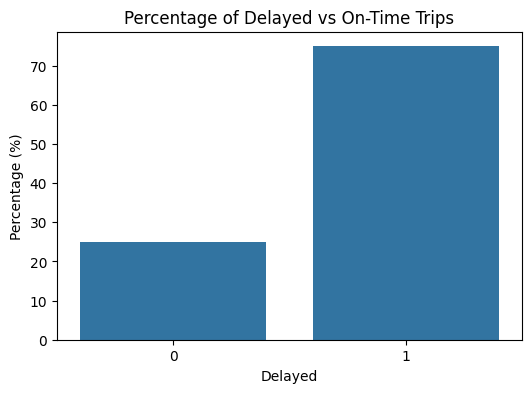

In [34]:
target_percentage = (
    df['delayed']
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)

target_percentage.columns = ['Delayed', 'Percentage']

plt.figure(figsize=(6, 4))

sns.barplot(
    data=target_percentage,
    x='Delayed',
    y='Percentage'
)

plt.title('Percentage of Delayed vs On-Time Trips')
plt.ylabel('Percentage (%)')
plt.xlabel('Delayed')

plt.show()

### Target Variable Analysis

The target variable `delayed` is imbalanced.

- 1,499 trips (74.95%) were delayed.
- 501 trips (25.05%) were not delayed.

Therefore, delayed trips represent the majority class, while on-time trips represent the minority class.

A baseline model that predicts every trip as delayed would already achieve approximately 74.95% accuracy. Consequently, accuracy alone would not be a sufficient metric for evaluating the classification models.

To address this issue, model evaluation will focus on Precision, Recall, F1-score, ROC-AUC and the Confusion Matrix. Class imbalance techniques such as class weighting and SMOTE will also be investigated during the preprocessing and modelling stages.

In [ ]:
# Missing event_type representation

# Missing = no event -> missing values have meaningful information 
# Missing = information not recorded -> treating as 'no event' is incorrect 

df['event_type'].value_counts(dropna=False)

event_type
NaN         1173
Festival     221
Sports       212
Concert      203
Parade       105
Protest       86
Name: count, dtype: int64

In [36]:
df[
    ['event_type', 'event_attendance_est']
].isnull().sum()

event_type              1173
event_attendance_est       0
dtype: int64

In [39]:
df[
    df['event_type'].isnull()
][
    ['event_type', 'event_attendance_est']
].head(20)

,event_type,event_attendance_est
0,NaN,500
1,NaN,0
3,NaN,500
4,NaN,500
7,NaN,0
9,NaN,50000
10,NaN,0
11,NaN,2000
13,NaN,10000
14,NaN,500


There are many missing event_type records where event attendance is clearly greater than 0.

So a missing event_type cannot reliably mean "No Event."

If we replaced every NaN with "No Event", we'd incorrectly classify records with event attendance of 50,000 as having no event.

In [40]:
pd.crosstab(
    df['event_type'].isnull(),
    df['event_attendance_est'] > 0,
    margins=True
)

event_attendance_est,False,True,All
event_type,,,
False,503,324,827
True,713,460,1173
All,1216,784,2000


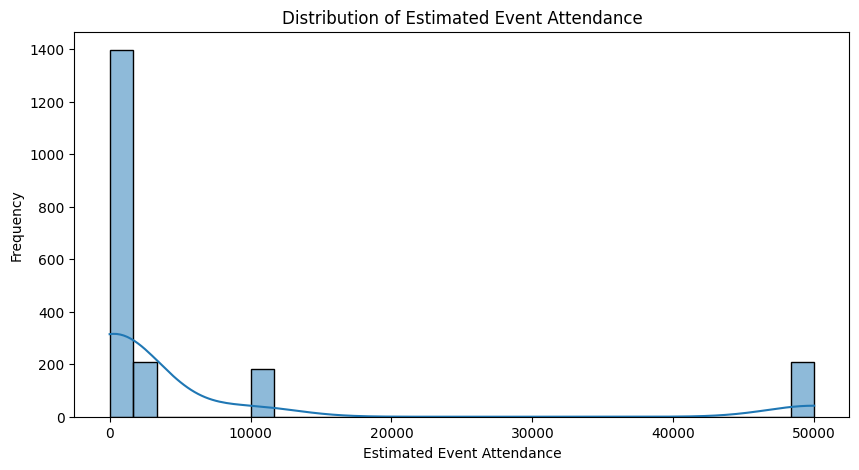

In [41]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='event_attendance_est',
    bins=30,
    kde=True
)

plt.title('Distribution of Estimated Event Attendance')

plt.xlabel('Estimated Event Attendance')

plt.ylabel('Frequency')

plt.show()

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


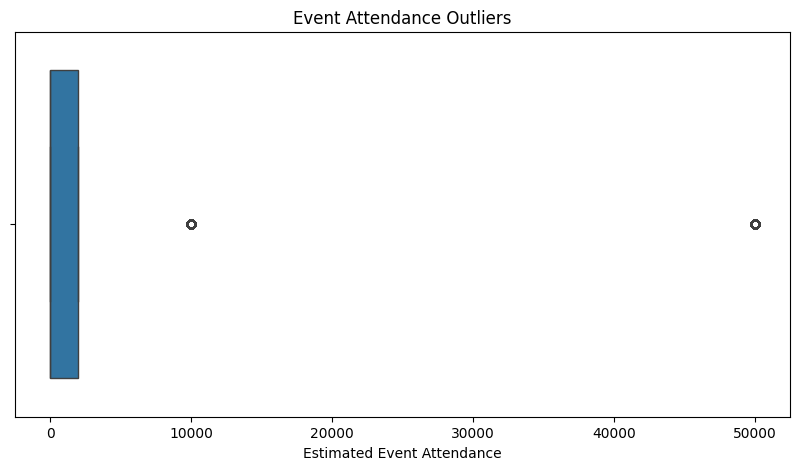

In [42]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x='event_attendance_est'
)

plt.title('Event Attendance Outliers')

plt.xlabel('Estimated Event Attendance')

plt.show()

### Event Type Missing Value Analysis

The `event_type` variable contains 1,173 missing observations out of 2,000
records. Further investigation was conducted using `event_attendance_est`
to determine whether these missing values represent trips without events.

The analysis found that 460 of the 1,173 records with missing `event_type`
have positive estimated event attendance. Therefore, missing `event_type`
cannot be interpreted as the absence of an event.

The missing values are consequently treated as an `Unknown` event type rather
than `No Event`.

A separate binary feature, `has_event`, will be created from
`event_attendance_est`, where trips with attendance greater than zero are
considered to have an event.

This approach preserves the information contained in both variables without
making an unsupported assumption about the meaning of the missing values.